In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# Load the Sample_dataset.csv
df = pd.read_csv('../data/raw/world_happiness_dataset.csv')

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head(22))
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (20, 8)

First few rows:
           Country  Happiness_Score  GDP_per_Capita  Social_Support  \
0           Norway             6.25            1.39            0.82   
1          Denmark             3.61            1.27            0.43   
2          Iceland             4.68            0.87            0.54   
3      Switzerland             4.46            0.67            0.57   
4          Finland             6.67            1.55            0.45   
5      Netherlands             6.41            0.87            0.54   
6           Canada             7.34            0.60            0.46   
7      New Zealand             3.87            0.61            0.57   
8        Australia             5.31            1.43            0.78   
9           Sweden             3.63            1.16            0.62   
10   United States             4.44            1.39            0.62   
11  United Kingdom             5.67            1.30            0.53   
12         Germany             3.61  

In [3]:
# Aggregation — rank countries by Happiness_Score
ranked = df.sort_values('Happiness_Score', ascending=False).reset_index(drop=True)

top3 = ranked.head(3)
lowest = ranked.tail(1)

print("Top 3 happiest countries:")
print(top3[['Country', 'Happiness_Score']])

print("\nLowest-happiness country:")
print(lowest[['Country', 'Happiness_Score', 'Freedom_to_Make_Choices']])

Top 3 happiest countries:
   Country  Happiness_Score
0   Canada             7.34
1   Brazil             6.98
2  Finland             6.67

Lowest-happiness country:
         Country  Happiness_Score  Freedom_to_Make_Choices
19  South Africa             3.53                      0.9


In [4]:
# Freedom score for the lowest-happiness country vs. the all-country average
avg_freedom = df['Freedom_to_Make_Choices'].mean()
sa_freedom = lowest['Freedom_to_Make_Choices'].values[0]
sa_country = lowest['Country'].values[0]

categories = [sa_country, 'All-country average']
values = [sa_freedom, avg_freedom]
colors = ['#2a78d6', '#9a9990']  # accent = subject, muted gray = context

print(f"{sa_country} Freedom score: {sa_freedom:.2f}  |  Average: {avg_freedom:.2f}")

South Africa Freedom score: 0.90  |  Average: 0.66


## Correlation — what actually predicts happiness?

Pearson correlation between `Happiness_Score` and every other factor, across all 20 countries.

In [5]:
factor_cols = ['GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy',
               'Freedom_to_Make_Choices', 'Generosity', 'Perceptions_of_Corruption']

correlations = df[factor_cols + ['Happiness_Score']].corr()['Happiness_Score'].drop('Happiness_Score')
correlations = correlations.sort_values()
corr_colors = ['#2a78d6' if v >= 0 else '#eb6834' for v in correlations]

print("Pearson correlation with Happiness_Score:")
print(correlations)

Pearson correlation with Happiness_Score:
Perceptions_of_Corruption   -0.342677
Generosity                  -0.145617
GDP_per_Capita               0.014073
Social_Support               0.022129
Freedom_to_Make_Choices      0.082801
Healthy_Life_Expectancy      0.159544
Name: Happiness_Score, dtype: float64


## Dashboard — ranking, correlation, and the outlier in one figure

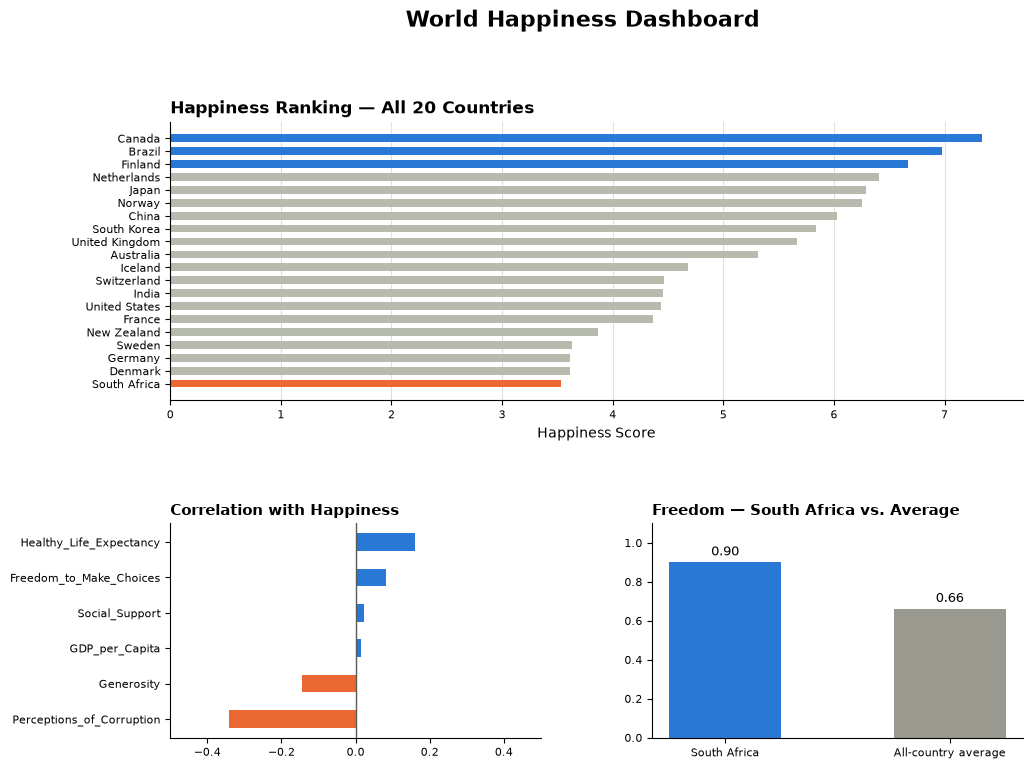

In [6]:
fig6 = plt.figure(figsize=(11, 8))
gs = fig6.add_gridspec(2, 2, height_ratios=[1.3, 1], hspace=0.5, wspace=0.3)

# Panel 1 — full ranking, spans both columns
ax_rank = fig6.add_subplot(gs[0, :])
rank_order = ranked.iloc[::-1]
rank_colors = ['#2a78d6' if c in top3['Country'].values else '#eb6834' if c == sa_country else '#b7bbad'
               for c in rank_order['Country']]
ax_rank.barh(rank_order['Country'], rank_order['Happiness_Score'], color=rank_colors, height=0.6)
ax_rank.set_title('Happiness Ranking — All 20 Countries', fontsize=12, fontweight='bold', loc='left')
ax_rank.set_xlabel('Happiness Score')
ax_rank.spines[['top', 'right']].set_visible(False)
ax_rank.grid(axis='x', color='#e0e0e0', linewidth=0.8, zorder=0)
ax_rank.set_axisbelow(True)
ax_rank.tick_params(labelsize=8)

# Panel 2 — correlation (bottom-left)
ax_corr = fig6.add_subplot(gs[1, 0])
ax_corr.barh(correlations.index, correlations.values, color=corr_colors, height=0.5)
ax_corr.axvline(0, color='#5b5c50', linewidth=1)
ax_corr.set_xlim(-0.5, 0.5)
ax_corr.set_title('Correlation with Happiness', fontsize=11, fontweight='bold', loc='left')
ax_corr.spines[['top', 'right']].set_visible(False)
ax_corr.tick_params(labelsize=8)

# Panel 3 — Freedom score outlier (bottom-right)
ax_free = fig6.add_subplot(gs[1, 1])
ax_free.bar(categories, values, color=colors, width=0.5)
for i, v in enumerate(values):
    ax_free.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
ax_free.set_title(f'Freedom — {sa_country} vs. Average', fontsize=11, fontweight='bold', loc='left')
ax_free.set_ylim(0, 1.1)
ax_free.spines[['top', 'right']].set_visible(False)
ax_free.tick_params(labelsize=8)

fig6.suptitle('World Happiness Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../figures/dashboard_matplotlib.png', dpi=150, bbox_inches='tight')
plt.show()

Same figure, interactive (Plotly) — hover any bar for its exact value.

In [7]:
rank_colors_full = ['#2a78d6' if c in top3['Country'].values else '#eb6834' if c == sa_country else '#b7bbad'
                     for c in ranked['Country']]

fig7 = make_subplots(
    rows=2, cols=2,
    specs=[[{"colspan": 2}, None], [{}, {}]],
    row_heights=[0.55, 0.45],
    subplot_titles=(
        "Happiness Ranking — All 20 Countries",
        "Correlation with Happiness",
        f"Freedom — {sa_country} vs. Average"
    ),
    vertical_spacing=0.15
)

fig7.add_trace(go.Bar(
    x=ranked['Happiness_Score'], y=ranked['Country'], orientation='h',
    marker_color=rank_colors_full, showlegend=False
), row=1, col=1)
fig7.update_yaxes(autorange='reversed', row=1, col=1)

fig7.add_trace(go.Bar(
    x=correlations.values, y=correlations.index, orientation='h',
    marker_color=corr_colors, showlegend=False
), row=2, col=1)
fig7.add_vline(x=0, line_color='#5b5c50', row=2, col=1)

fig7.add_trace(go.Bar(
    x=categories, y=values, marker_color=colors, showlegend=False
), row=2, col=2)

fig7.update_layout(
    title='World Happiness Dashboard',
    template='plotly_white',
    height=750,
    margin=dict(l=110, r=40, t=90, b=40)
)

fig7.write_image('../figures/dashboard_plotly.png', scale=2)
fig7.show()

## Findings

- **Top 3 happiest**: Canada (7.34), Brazil (6.98), Finland (6.67).
- **Lowest happiness**: South Africa (3.53), yet its Freedom score (0.90) sits above the
  20-country average (0.65) — the opposite of what a naive read would predict.
- **Why**: across all 20 countries, no factor correlates strongly with Happiness_Score —
  the strongest is Perceptions_of_Corruption at only r = −0.34, and GDP, Social Support
  and Freedom are all under 0.16. That weak-correlation result, not the South Africa case
  on its own, is the evidence that no single factor in this dataset drives the happiness
  outcome.
- **Chart choice**: horizontal bars for country comparisons (length is the most accurately
  judged channel, and labels don't need rotating); a diverging bar for the correlation
  panel, since that data has a sign and a meaningful zero.